In [1]:
#!pip install -q \
#    diffusers==0.30.0 \
#    transformers==4.44.0 \
#    huggingface_hub==0.24.0 \
#    accelerate==0.33.0 \
#    peft==0.12.0 \
#    torchao==0.16.0

#import os
#os.kill(os.getpid(), 9)

## Importation des bibliothèques

In [1]:
from google.colab import drive
import zipfile, os
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import random
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.amp import autocast, GradScaler
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler, StableDiffusionPipeline
from transformers import CLIPTextModel, CLIPTokenizer
from transformers import pipeline as hf_pipeline
from peft import LoraConfig, get_peft_model

## Extraction des images

In [2]:
drive.mount('/content/drive')

# Extraire sketch.zip
zip_path = "/content/drive/MyDrive/sketch.zip"
extract_path = "/content/raw_dataset"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Nettoyage et préparation du dataset

In [3]:
src = "/content/raw_dataset/sketch"
data_dir = "/content/dataset"
os.makedirs(data_dir, exist_ok=True)
CAPTION = "hand drawn pencil sketch, grayscale, black and white ink lines, white background, minimalist, no color, no shading, clean strokes, hand drawn illustration"

extensions = (".jpg", ".jpeg", ".png")
images = [f for f in os.listdir(src) if f.lower().endswith(extensions)]
random.shuffle(images)

valid = 0
for i, fname in enumerate(images):
    try:
        #Chargement de l'image
        img = Image.open(f"{src}/{fname}")
        img = img.convert("L")
        img = ImageOps.autocontrast(img)
        img = img.convert("RGB")

        img.thumbnail((512, 512), Image.LANCZOS)
        padded = Image.new("RGB", (512, 512), (255, 255, 255))
        offset = ((512 - img.width) // 2, (512 - img.height) // 2)
        padded.paste(img, offset)

        name = f"sketch_{i:03d}"
        padded.save(f"{data_dir}/{name}.jpg", "JPEG", quality=95)
        with open(f"{data_dir}/{name}.txt", "w") as f:
            f.write(CAPTION)
        valid += 1
    except Exception as e:
        print(f"Ignorée : {fname} — {e}")

print(f"données : {valid} images")

données : 319 images


## Visualisation

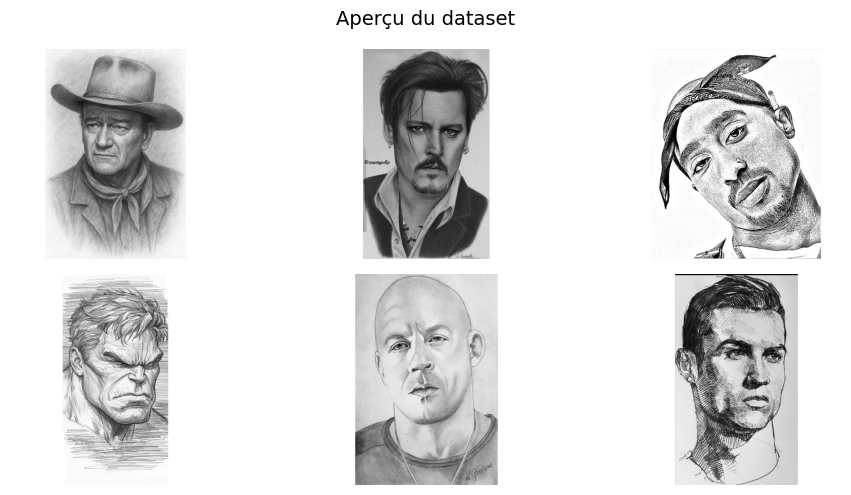

In [4]:
samples = [f for f in os.listdir("/content/dataset") if f.endswith(".jpg")]
samples = random.sample(samples, min(6, len(samples)))

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
for ax, fname in zip(axes.flat, samples):
    img = Image.open(f"/content/dataset/{fname}")
    ax.imshow(img)
    ax.axis("off")
plt.suptitle("Aperçu du dataset", fontsize=14)
plt.tight_layout()
plt.show()

## Chargement de Stable Diffusion 1.5

In [5]:
model_id = "runwayml/stable-diffusion-v1-5"

tokenizer    = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to("cuda")
vae          = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to("cuda")
unet         = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to("cuda")
scheduler    = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# Geler VAE et text encoder
vae.requires_grad_(False)
text_encoder.requires_grad_(False)

# COnfiguration du LoRA
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=0.05,
    bias="none"
)
# Application du LoRA
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


trainable params: 6,377,472 || all params: 865,898,436 || trainable%: 0.7365


## Création du dataset PyTorch


In [7]:
class SketchDataset(Dataset):
    def __init__(self, folder, tokenizer, size=512):
        self.folder = folder
        self.tokenizer = tokenizer
        self.images = sorted([f for f in os.listdir(folder) if f.endswith(".jpg")])
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]
        img = Image.open(f"{self.folder}/{name}").convert("RGB")
        caption = open(f"{self.folder}/{name.replace('.jpg', '.txt')}").read().strip()

        pixel_values = self.transform(img)
        input_ids = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=tokenizer.model_max_length,
            return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "input_ids": input_ids}


dataset = SketchDataset("/content/dataset", tokenizer)

data_loader  = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Train : {len(dataset)} images | {len(data_loader)} batchs")

Train : 319 images | 80 batchs


## Entrainement

Epoch   1/50 | Loss: 0.0966 
Epoch   2/50 | Loss: 0.1023 
Epoch   3/50 | Loss: 0.1063 
Epoch   4/50 | Loss: 0.1041 
Epoch   5/50 | Loss: 0.1019 
Epoch   6/50 | Loss: 0.1074 
Epoch   7/50 | Loss: 0.1079 
Epoch   8/50 | Loss: 0.0948 
Epoch   9/50 | Loss: 0.0888 
Epoch  10/50 | Loss: 0.1040 
Epoch  11/50 | Loss: 0.0925 
Epoch  12/50 | Loss: 0.0997 
Epoch  13/50 | Loss: 0.0937 
Epoch  14/50 | Loss: 0.1052 
Epoch  15/50 | Loss: 0.1012 
Epoch  16/50 | Loss: 0.1057 
Epoch  17/50 | Loss: 0.0897 
Epoch  18/50 | Loss: 0.1068 
Epoch  19/50 | Loss: 0.1004 
Epoch  20/50 | Loss: 0.1025 
Epoch  21/50 | Loss: 0.1069 
Epoch  22/50 | Loss: 0.0967 
Epoch  23/50 | Loss: 0.1011 
Epoch  24/50 | Loss: 0.1074 
Epoch  25/50 | Loss: 0.0995 
Epoch  26/50 | Loss: 0.0981 
Epoch  27/50 | Loss: 0.0947 
Epoch  28/50 | Loss: 0.0939 
Epoch  29/50 | Loss: 0.1006 
Epoch  30/50 | Loss: 0.0982 
Epoch  31/50 | Loss: 0.1060 
Epoch  32/50 | Loss: 0.0984 
Epoch  33/50 | Loss: 0.0961 
Epoch  34/50 | Loss: 0.1065 
Epoch  35/50 |

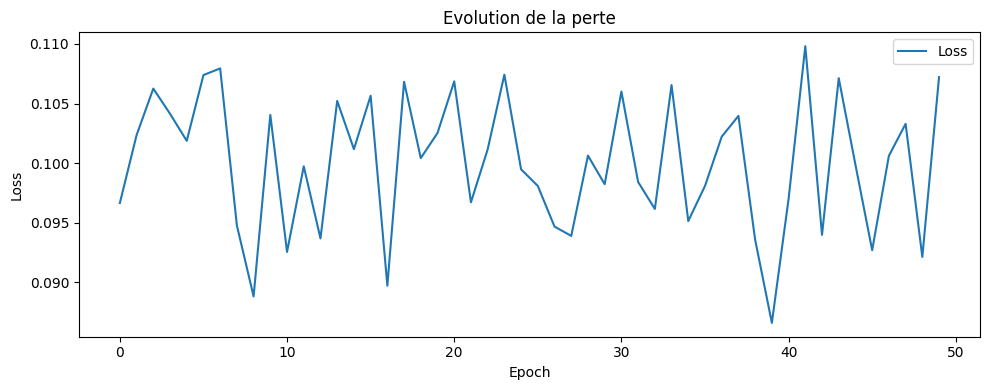

In [9]:
optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=1e-4,
    weight_decay=1e-2
)
scaler = GradScaler()
EPOCHS = 50
losses = []

weight_dtype = torch.float16
text_encoder.to(dtype=weight_dtype)
vae.to(dtype=weight_dtype)

unet.to(dtype=torch.float32)
for name, param in unet.named_parameters():
    if not param.requires_grad:
        param.data = param.data.to(torch.float16)

# ------------- BOUCLE D'ENTRAINEMENT --------------
unet.train()
for epoch in range(EPOCHS):
    total_losses = 0
    for batch in data_loader:
        pv  = batch["pixel_values"].to("cuda", dtype=weight_dtype)
        ids = batch["input_ids"].to("cuda")

        with torch.no_grad():
            latents = vae.encode(pv).latent_dist.sample() * vae.config.scaling_factor
            enc_hs  = text_encoder(ids)[0]

        noise     = torch.randn_like(latents)
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps,
                                  (latents.shape[0],), device="cuda").long()
        noisy     = scheduler.add_noise(latents, noise, timesteps)

        with autocast(device_type='cuda'):
            pred = unet(noisy, timesteps, enc_hs).sample
            loss = torch.nn.functional.mse_loss(pred.float(), noise.float())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        total_losses += loss.item()

    avg_loss = total_losses / len(data_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1:>3}/{EPOCHS} | Loss: {avg_loss:.4f} ")

# ----------- COURBE DE LOSS -----------
plt.figure(figsize=(10, 4))
plt.plot(losses, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolution de la perte")
plt.legend()
plt.tight_layout()
plt.show()

## Sauvegarde du modèle

In [10]:
final_path = "/content/drive/MyDrive/lora_sketch_sd15_v2"

# Sauvegarder des poids
unet.save_pretrained(final_path)

In [11]:
# Traducteur
translator = hf_pipeline("translation", model="Helsinki-NLP/opus-mt-fr-en")

# Création le pipeline de génération
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    unet=unet,
    torch_dtype=torch.float16
).to("cuda")
pipe.safety_checker = None

def generate_sketch(prompt_fr):
    prompt_en = translator(prompt_fr)[0]['translation_text']
    print(f"Traduit : {prompt_en}")

    image = pipe(
        prompt=prompt_en + ", hand drawn pencil sketch, grayscale",
        negative_prompt="color, realistic, photo, painting",
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]
    return image

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

...

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

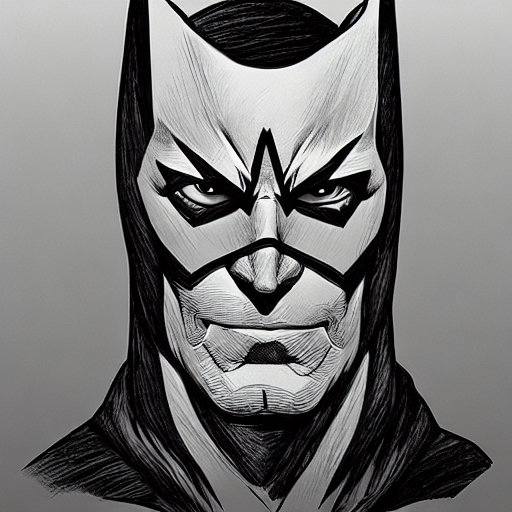

In [13]:
image1 = pipe(prompt="un superhero, sketch, grayscale").images[0]

display(image1)

In [14]:
# ── Pipeline SD 1.5 vanilla (sans LoRA) ──
unet_vanilla = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")
pipe_vanilla = StableDiffusionPipeline.from_pretrained(
    model_id, unet=unet_vanilla, torch_dtype=torch.float16
).to("cuda")
pipe_vanilla.safety_checker = None

# ── Pipeline SD 1.5 + LoRA ──
pipe_lora = StableDiffusionPipeline.from_pretrained(
    model_id, unet=unet, torch_dtype=torch.float16
).to("cuda")
pipe_lora.safety_checker = None

unet_vanilla.to(dtype=torch.float16)
unet.to(dtype=torch.float16)

def compare(prompt_fr, num_inference_steps=30, guidance_scale=7.5):
    prompt_en = translator(prompt_fr)[0]['translation_text']
    print(f"Traduit : {prompt_en}")

    with torch.no_grad():
        img_vanilla = pipe_vanilla(
            prompt=prompt_en,
            negative_prompt="blurry, low quality",
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale
        ).images[0]

        img_lora = pipe_lora(
            prompt=prompt_en,
            negative_prompt="color, realistic, photo, painting",
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale
        ).images[0]

    # Afficher côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_vanilla)
    axes[0].set_title("SD 1.5 vanilla", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(img_lora)
    axes[1].set_title("SD 1.5 + LoRA sketch", fontsize=12)
    axes[1].axis("off")

    plt.suptitle(f'"{prompt_fr}"  →  "{prompt_en}"', fontsize=11)
    plt.tight_layout()
    plt.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Traduit : a cat sitting on a chair, sketch, shade of grey


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

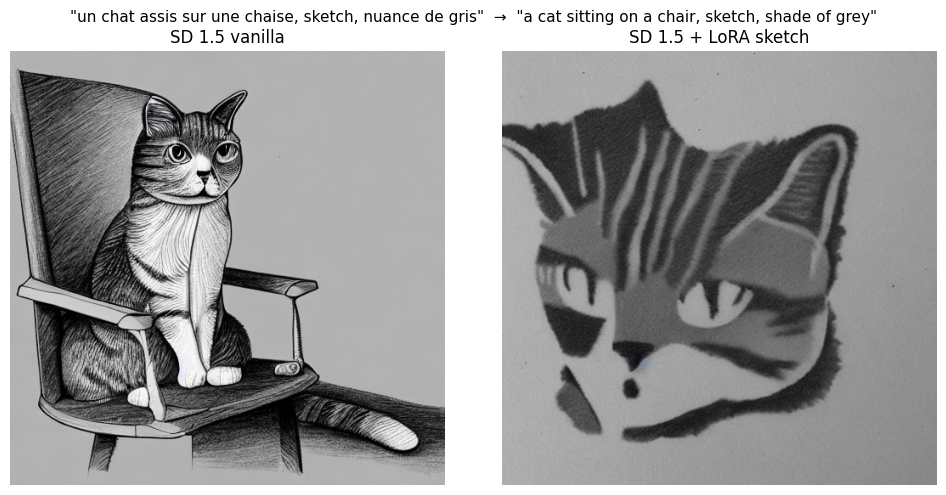

Traduit : a car in the street, sketch, shade of gray


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

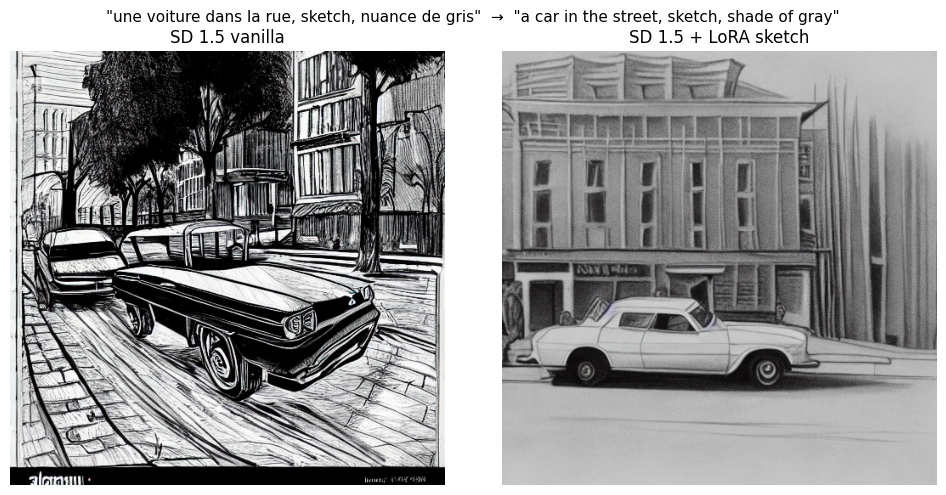

Traduit : a tree in a garden, sketch, shade of grey


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

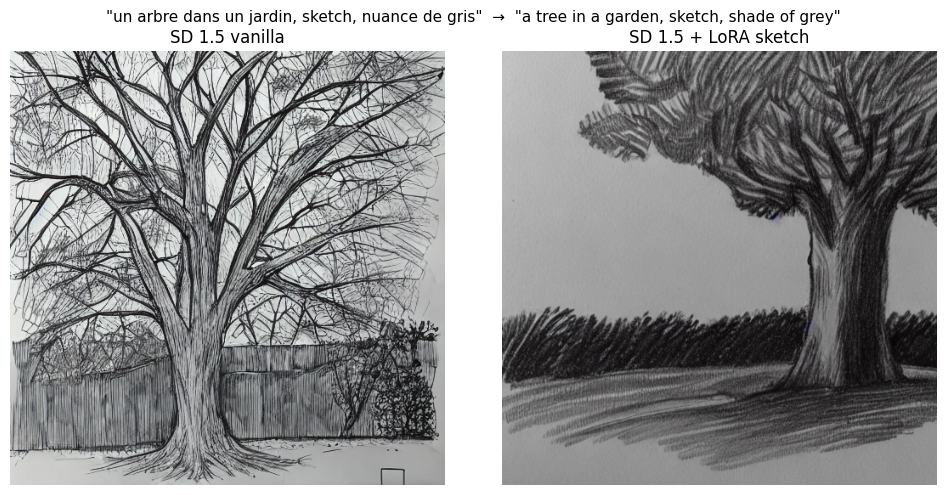

Traduit : a superhero flying towards a city, sketch, shade of gray


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

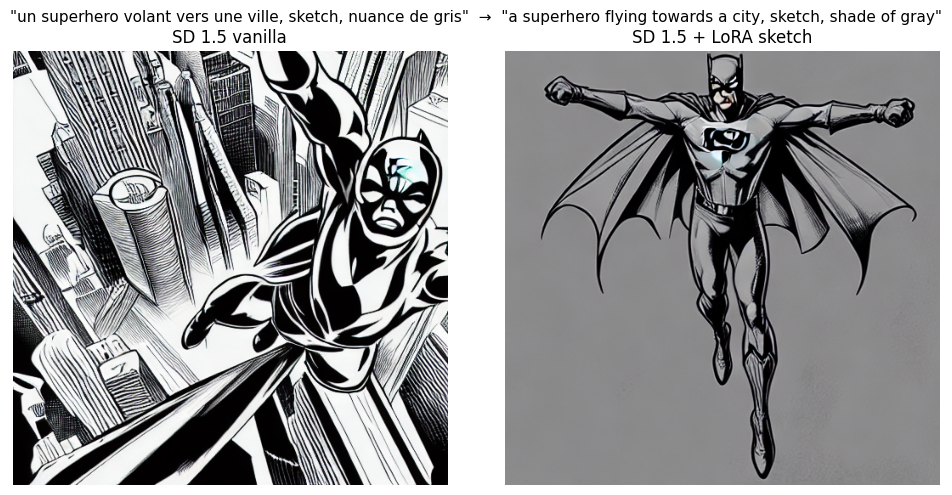

Traduit : a man driving a car, sketch, shade of gray


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

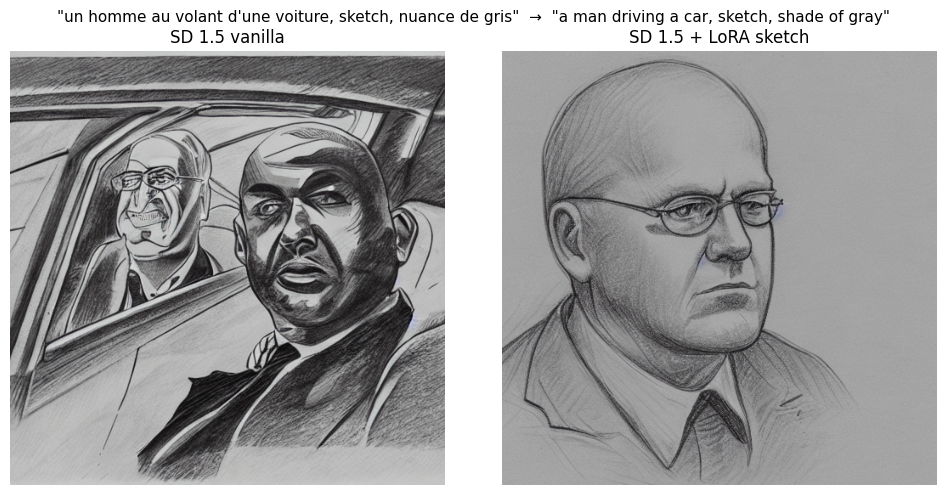

Traduit : a smiling woman, sketch, shade of grey


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

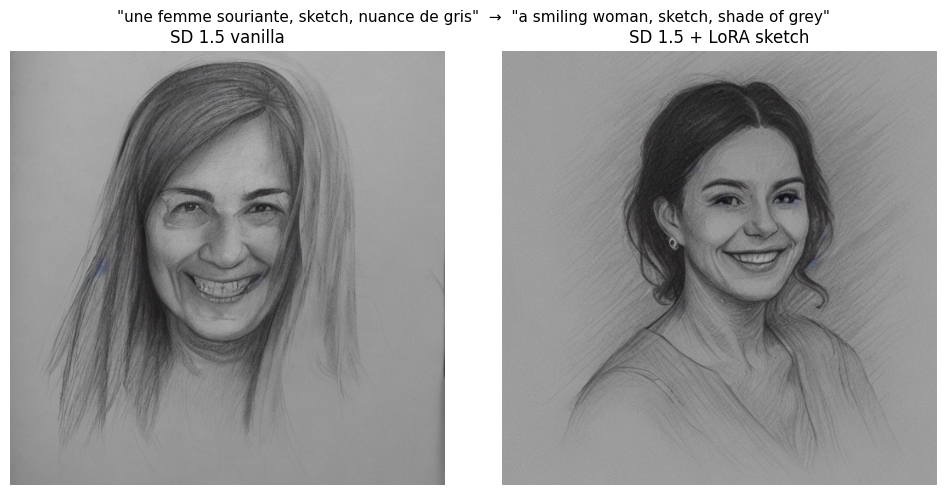

In [15]:
# ── Test ──
compare("un chat assis sur une chaise, sketch, nuance de gris")
compare("une voiture dans la rue, sketch, nuance de gris")
compare("un arbre dans un jardin, sketch, nuance de gris")
compare("un superhero volant vers une ville, sketch, nuance de gris")
compare("un homme au volant d'une voiture, sketch, nuance de gris")
compare("une femme souriante, sketch, nuance de gris")